<a href="https://colab.research.google.com/github/t-sasatani/wpt-analysis/blob/main/examples/measurement_sample.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
import sys
from pathlib import Path

# Prefer local workspace package during development.
repo_root = Path.cwd().resolve().parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

if "COLAB_GPU" in os.environ:
    !pip install git+https://github.com/t-sasatani/wpt-tools

In [2]:
from wpt_tools.data_classes import RichNetwork
from wpt_tools.analysis import MinMax, nw_tools
from wpt_tools.plotter import plot_impedance

### Create instance of analysis and set initial variables

In [3]:
example_nw = RichNetwork.from_touchstone("./assets/HWPT/test.s2p")
#example_nw.set_f_target_range(target_f=6.63e6, range_f=1e6)
example_nw.set_f_target_range(target_f=13.56e6, range_f=1e6)

### Plot Z-parameters (full-range)

2026-06-18 21:50:27 [INFO] wpt_tools.plotter: Plotting impedance. full_range=True


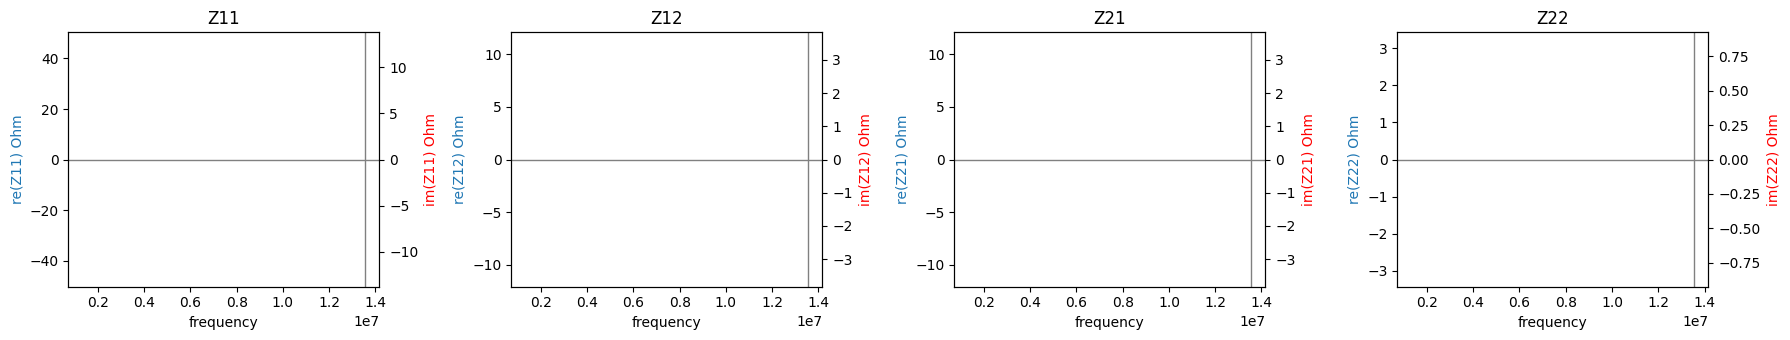

In [4]:
_ = plot_impedance(example_nw, full_range=True, target_f=6.63e6)

### Efficiency and optimal load analysis (for general 2-port networks)
This becomes unstable when the analysis frequency is far from the resonant frequency.
This is probably because to S to Z conversion becomes unstable.

2026-06-18 21:50:32 [INFO] wpt_tools.plotter: Plotting efficiency results.


╒════════════════════╤═════════╕
│ Parameter          │ Value   │
╞════════════════════╪═════════╡
│ Target frequency   │         │
├────────────────────┼─────────┤
│ Maximum efficiency │         │
├────────────────────┼─────────┤
│ Optimum Re(Zload)  │         │
├────────────────────┼─────────┤
│ Optimum Im(Zload)  │         │
╘════════════════════╧═════════╛


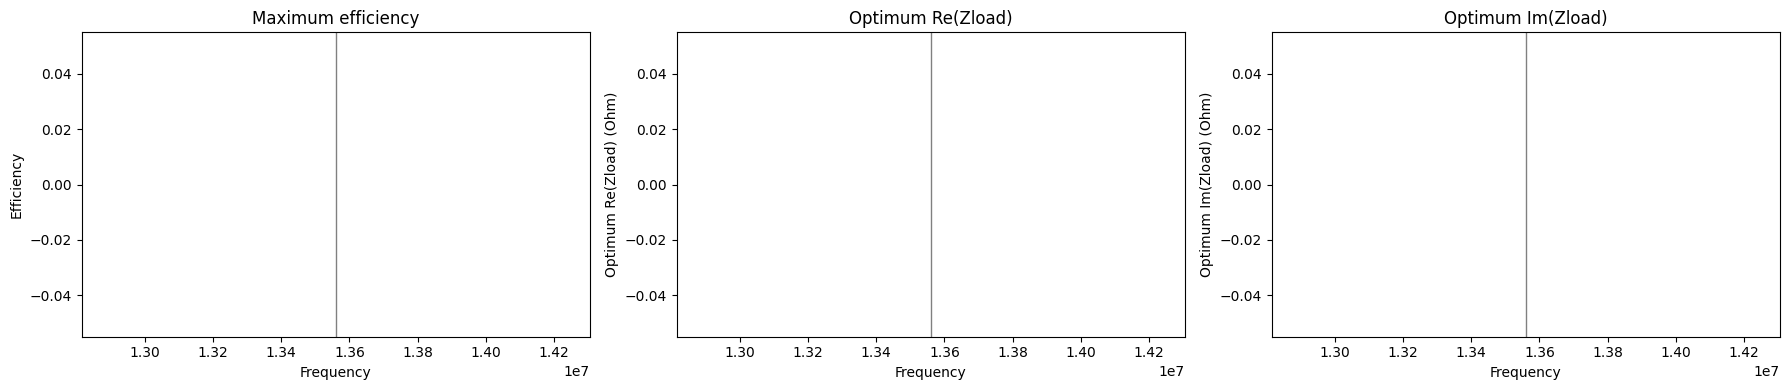

In [5]:
_ = nw_tools.analyze_efficiency(
    rich_nw=example_nw, show_plot=True, show_data=True, rx_port=2
)

### Curve-fitting and Z-matrix plot (only for 2-port measurement of Series-Series LCR coupling)

In [6]:
# For maximum efficiency analysis
target_f = 13.56e6
range_f = 1e5

_ = nw_tools.fit_z_narrow(
    rich_nw=example_nw, show_plot=True, target_f=target_f, range_f=range_f
)

TypeError: Improper input: func input vector length N=2 must not exceed func output vector length M=1

### Optimal load visualization

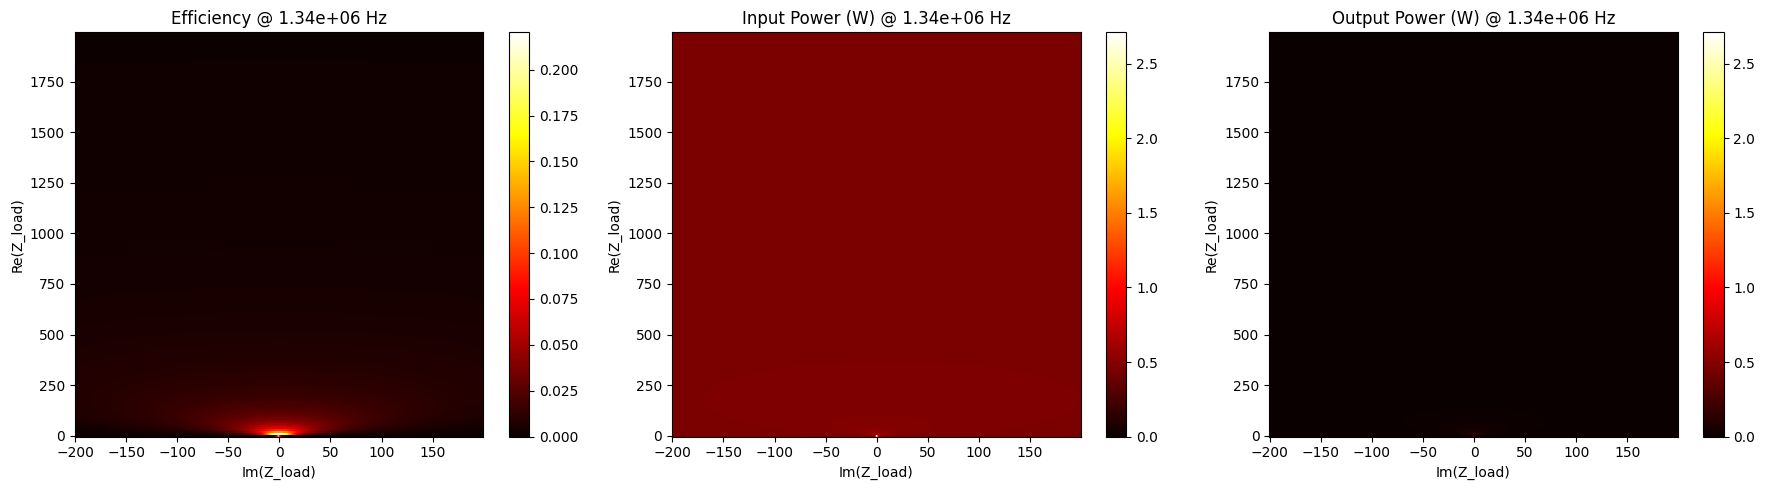

In [7]:
_ = nw_tools.sweep_load(
    rich_nw=example_nw,
    rez_range=MinMax(min=0.1, max=2000, step=10),
    imz_range=MinMax(min=-200, max=200, step=1),
    input_voltage=5,
    rx_port=2,
    show_plot=True,
)

### Capacitor filter calculator
![](https://github.com/t-sasatani/wpt-analysis/blob/main/examples/img/CpCsRltopology.png?raw=1)

In [ ]:
nw_tools.calc_rxc_filter(rich_nw=example_nw, rx_port=2, rload=1000, c_network="CpCsRl")

In [8]:
# gmax only (maximum efficiency)
f0 = float(example_nw.nw.frequency.f[0])
results = nw_tools.analyze_efficiency(
    rich_nw=example_nw,
    rx_port=2,
    show_plot=False,
    show_data=False,
    target_f=f0,
    range_f=max(1.0, 2.0 * abs(f0) + 1.0),
)
gmax = results.max_eff_opt
print(gmax)

0.45715034900635365


In [ ]:
from pathlib import Path
import re
import numpy as np
import matplotlib.pyplot as plt

hwpt_dir = Path("./assets/HWPT")
paths = sorted(hwpt_dir.glob("RelaykQ_*_*.s2p"))

rows = []
for p in paths:
    m = re.match(r"RelaykQ_(\d+)_(\d+)\.s2p$", p.name)
    if m is None:
        continue

    # i_j means i.j meters (e.g., 0_35 -> 0.35 m)
    dist_m = float(f"{m.group(1)}.{m.group(2)}")

    rich_nw = RichNetwork.from_touchstone(str(p))
    f0 = float(rich_nw.nw.frequency.f[0])
    fr = max(1.0, 2.0 * abs(f0) + 1.0)
    rich_nw.set_f_target_range(target_f=f0, range_f=fr)
    eff = nw_tools.analyze_efficiency(
        rich_nw=rich_nw,
        rx_port=2,
        show_plot=False,
        show_data=False,
    )

    gmax = float(eff.max_eff_opt)
    # Inverse mapping from eta_max to kq
    s = (1.0 + gmax) / (1.0 - gmax)
    kq = float(np.sqrt(s * s - 1.0))

    rows.append((dist_m, gmax, kq, p.name))

rows.sort(key=lambda x: x[0])
dist = np.array([r[0] for r in rows], dtype=float)
gmax_arr = np.array([r[1] for r in rows], dtype=float)
kq_arr = np.array([r[2] for r in rows], dtype=float)

print(f"Loaded {len(rows)} HWPT files")
print("distance[m]   gmax      kq      file")
for d, g, k, fname in rows:
    print(f"{d:>9.3f}   {g:>6.4f}   {k:>6.3f}   {fname}")

# Graph 1: efficiency vs distance
fig1, ax1 = plt.subplots(figsize=(7, 4))
ax1.plot(dist, gmax_arr, marker="o", linewidth=1.8)
ax1.set_xlabel("Distance x [m]")
ax1.set_ylabel("Efficiency (gmax)")
ax1.set_title("HWPT: Efficiency vs Distance")
ax1.grid(alpha=0.3)
fig1.tight_layout()
fig1

# Graph 2: kq vs distance
fig2, ax2 = plt.subplots(figsize=(7, 4))
ax2.plot(dist, kq_arr, marker="o", linewidth=1.8, color="tab:orange")
ax2.set_xlabel("Distance x [m]")
ax2.set_ylabel("kq")
ax2.set_title("HWPT: kq vs Distance")
ax2.grid(alpha=0.3)
fig2.tight_layout()
fig2

### HWPT: efficiency and kq vs distance
Parse distance from filenames like `RelaykQ_0_35.s2p` -> `0.35 m`, then plot:
1. x = distance [m], y = maximum efficiency
2. x = distance [m], y = kq